Поточна робоча папка:
c:\programas\diploma\data\notebooks
Файл знайдено: ..\data_raw\application_train.csv
Кількість рядків: 307511
Кількість ознак: 122

Розподіл ознак за типами даних


,Тип даних,Кількість ознак
0,float64,65
1,int64,41
2,object,16



Перевірка унікальності SK_ID_CURR


,Показник,Кількість,"Частка, %"
0,Дублюючі значення SK_ID_CURR,0,0.0



20 ознак з найбільшою часткою пропущених значень


,Ознака,Кількість пропусків,"Частка пропусків, %"
48,COMMONAREA_AVG,214865,69.87
62,COMMONAREA_MODE,214865,69.87
76,COMMONAREA_MEDI,214865,69.87
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
70,NONLIVINGAPARTMENTS_MODE,213514,69.43
56,NONLIVINGAPARTMENTS_AVG,213514,69.43
86,FONDKAPREMONT_MODE,210295,68.39
54,LIVINGAPARTMENTS_AVG,210199,68.35
82,LIVINGAPARTMENTS_MEDI,210199,68.35
68,LIVINGAPARTMENTS_MODE,210199,68.35



Ознаки з часткою пропущених значень понад 60%


,Ознака,Кількість пропусків,"Частка пропусків, %"
48,COMMONAREA_AVG,214865,69.87
62,COMMONAREA_MODE,214865,69.87
76,COMMONAREA_MEDI,214865,69.87
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
70,NONLIVINGAPARTMENTS_MODE,213514,69.43
56,NONLIVINGAPARTMENTS_AVG,213514,69.43
86,FONDKAPREMONT_MODE,210295,68.39
54,LIVINGAPARTMENTS_AVG,210199,68.35
82,LIVINGAPARTMENTS_MEDI,210199,68.35
68,LIVINGAPARTMENTS_MODE,210199,68.35


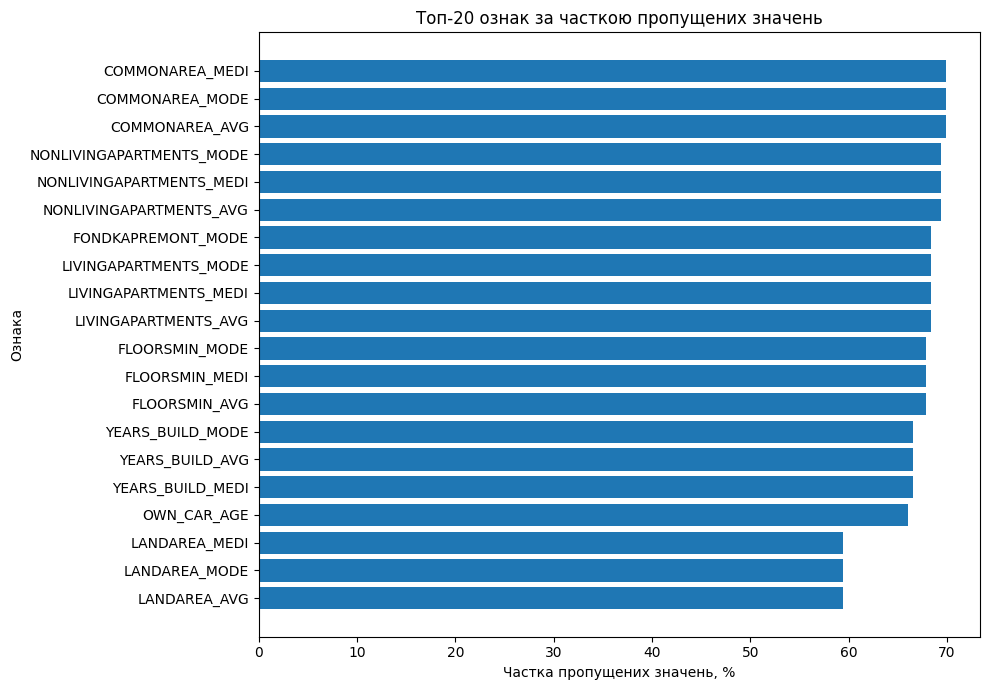


Розподіл цільової змінної TARGET


,TARGET,Характеристика класу,"Частка, %"
0,0,Клієнти без дефолту,91.93
1,1,Клієнти з дефолтом,8.07


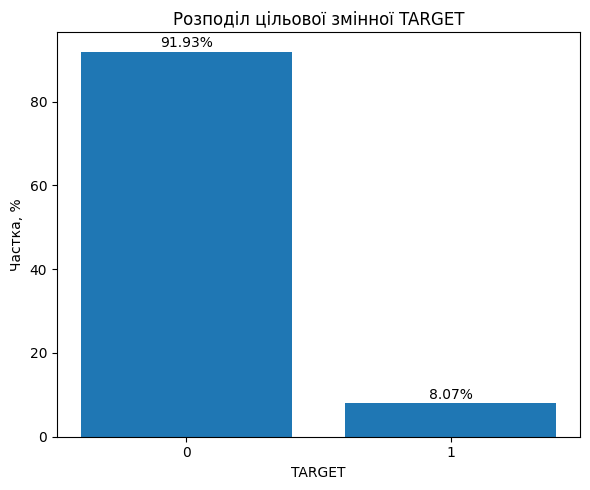


ТРезультати перевірки набору даних на потенційні аномальні значення


,Ознака,Тип потенційної проблеми,Кількість,"Частка, %",Коментар
18,FLAG_OWN_CAR,"Значення не з множини {0, 1}",307511,100.0000,Бінарна ознака повинна містити лише 0 або 1
19,FLAG_OWN_REALTY,"Значення не з множини {0, 1}",307511,100.0000,Бінарна ознака повинна містити лише 0 або 1
0,DAYS_EMPLOYED,Фіктивне значення 365243,55374,18.0072,Значення не відповідає реальному трудовому стажу
7,ORGANIZATION_TYPE,Службова категорія XNA,55374,18.0072,Може означати невизначене або службове значення
15,CNT_CHILDREN,Нетипово велика кількість дітей,8,0.0026,Може бути потенційним викидом
6,CODE_GENDER,Службова категорія XNA,4,0.0013,Може означати невизначене або службове значення
16,CNT_FAM_MEMBERS,Нетипово велика кількість членів сім’ї,4,0.0013,Може бути потенційним викидом



Топ-20 числових ознак за часткою потенційних викидів


,Ознака,Кількість потенційних викидів,"Частка потенційних викидів, %",Мінімальне значення,Максимальне значення,Нижня межа IQR,Верхня межа IQR
7,DAYS_EMPLOYED,72217,23.4844,-17912.0,365243.0,-6466.5000,3.417500e+03
59,OBS_30_CNT_SOCIAL_CIRCLE,19971,6.4944,0.0,348.0,-3.0000,5.000000e+00
60,OBS_60_CNT_SOCIAL_CIRCLE,19564,6.3620,0.0,344.0,-3.0000,5.000000e+00
43,NONLIVINGAREA_MODE,18817,6.1191,0.0,1.0,-0.0346,5.780000e-02
57,NONLIVINGAREA_MEDI,17254,5.6109,0.0,1.0,-0.0399,6.650000e-02
29,NONLIVINGAREA_AVG,16546,5.3806,0.0,1.0,-0.0415,6.920000e-02
28,NONLIVINGAPARTMENTS_AVG,15580,5.0665,0.0,1.0,-0.0058,9.700000e-03
56,NONLIVINGAPARTMENTS_MEDI,15215,4.9478,0.0,1.0,-0.0058,9.700000e-03
4,AMT_GOODS_PRICE,14728,4.7894,40500.0,4050000.0,-423000.0000,1.341000e+06
42,NONLIVINGAPARTMENTS_MODE,14224,4.6255,0.0,1.0,-0.0058,9.700000e-03



Підсумок перевірки якості даних:
- Кількість рядків: 307511
- Кількість ознак: 122
- Кількість ознак з пропусками понад 60%: 17
- Кількість дублікатів SK_ID_CURR: 0
- Частка клієнтів із дефолтом: 8.07%
- Кількість перевірок з виявленими потенційними проблемами: 7


In [ ]:
# Модуль аналізу якості датасету Home Credit Default Risk
# Перевіряє типи даних, пропуски, дублікати, аномалії, викиди


import os
from pathlib import Path

# Зовнішні бібліотеки для роботи з даними та візуалізацією
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IPython.display використовується для красивого виводу таблиць у Jupyter
try:
    from IPython.display import display
except ImportError:
    display = print

# Шукає файл application_train.csv спочатку у стандартних відносних шляхах проєкту,
# якщо не знайдено — рекурсивно сканує всю робочу директорію.
# Повертає Path до першого знайденого файлу або викидає FileNotFoundError.
def find_data_file():
    # Перелік типових розташувань файлу відносно поточної директорії
    possible_paths = [
        Path("application_train.csv"),               
        Path("data_raw/application_train.csv"),       
        Path("data/data_raw/application_train.csv"),  
        Path("../data_raw/application_train.csv"),    
        Path("../data/data_raw/application_train.csv"),
        Path("../../data/data_raw/application_train.csv")  
    ]

    # Перевіряємо кожен шлях по черзі
    for path in possible_paths:
        if path.exists():
            # Файл знайдено — повертаємо одразу, без подальшого пошуку
            return path

    # Якщо жоден зі стандартних шляхів не підійшов — шукаємо рекурсивно
    found_files = list(Path.cwd().rglob("application_train.csv"))

    if len(found_files) > 0:
        # Беремо перший знайдений файл у списку
        return found_files[0]

    # Файл не знайдено жодним з методів — повідомляємо про помилку
    raise FileNotFoundError("Файл application_train.csv не знайдено.")


# Викликає find_data_file(), зчитує CSV у датафрейм та виводить
# шлях до файлу, кількість рядків і кількість ознак.
# Повертає завантажений датафрейм.
def load_dataset():
    # Визначаємо шлях до файлу через допоміжну функцію
    data_path = find_data_file()

    # Зчитуємо CSV у pandas DataFrame; усі типи визначаються автоматично
    data = pd.read_csv(data_path)

    # Виводимо базову інформацію для підтвердження успішного завантаження
    print("Файл знайдено:", data_path)
    print("Кількість рядків:", data.shape[0])
    print("Кількість ознак:", data.shape[1])

    return data


# Створює вихідні папки outputs/tables і outputs/figures, якщо вони ще не існують.
# Повертає Path-об'єкти для обох папок.
def create_output_folders():
    # Папка для збереження таблиць у форматі CSV
    tables_dir = Path("outputs/tables")

    # Папка для збереження графіків у форматі PNG
    figures_dir = Path("outputs/figures")

    # parents=True дозволяє створити всі проміжні директорії
    # exist_ok=True не викидає помилку, якщо папка вже існує
    tables_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    return tables_dir, figures_dir


# Підраховує кількість ознак кожного типу даних (int64, float64, object тощо).
# Повертає таблицю з двома колонками: тип даних і кількість ознак.
def get_data_type_table(data):
    # dtypes повертає Series з типом кожної колонки
    # astype(str) конвертує dtype-об'єкти у читабельні рядки
    # value_counts() рахує кількість ознак кожного типу
    type_table = (
        data.dtypes
        .astype(str)
        .value_counts()
        .reset_index()
    )

    # Перейменовуємо колонки для зрозумілого відображення
    type_table.columns = ["Тип даних", "Кількість ознак"]

    return type_table


# Перевіряє наявність дублікатів за колонкою SK_ID_CURR.
# Якщо колонка відсутня — повертає таблицю-заглушку з NaN.
# Інакше повертає таблицю з кількістю та часткою дублюючих ідентифікаторів.
def check_id_duplicates(data):
    # Якщо ключова колонка відсутня — повертаємо інформативну заглушку
    if "SK_ID_CURR" not in data.columns:
        return pd.DataFrame({
            "Показник": ["SK_ID_CURR не знайдено"],
            "Кількість": [np.nan],
            "Частка, %": [np.nan]
        })

    # duplicated() повертає булеву маску: True для рядків, що повторюються
    duplicate_count = data.duplicated("SK_ID_CURR").sum()

    # Обчислюємо частку дублікатів відносно загальної кількості рядків
    duplicate_percent = duplicate_count / len(data) * 100

    # Формуємо підсумкову таблицю з одним рядком результату
    duplicate_table = pd.DataFrame({
        "Показник": ["Дублюючі значення SK_ID_CURR"],
        "Кількість": [duplicate_count],
        "Частка, %": [round(duplicate_percent, 4)]
    })

    return duplicate_table


# Обчислює кількість і частку пропущених значень для кожної ознаки датасету.
# Повертає таблицю, відсортовану за спаданням частки пропусків.
def get_missing_values_table(data):
    # isna().sum() повертає кількість NaN по кожній колонці
    missing_table = data.isna().sum().reset_index()

    # Встановлюємо зрозумілі назви колонок
    missing_table.columns = ["Ознака", "Кількість пропусків"]

    # Обчислюємо відносну частку пропусків у відсотках
    missing_table["Частка пропусків, %"] = (
        missing_table["Кількість пропусків"] / len(data) * 100
    ).round(2)

    # Сортуємо за спаданням: найпроблемніші ознаки — вгорі
    missing_table = missing_table.sort_values(
        by="Частка пропусків, %",
        ascending=False
    )

    return missing_table


# Будує горизонтальну діаграму для топ-20 ознак із найбільшою часткою пропусків.
# Зберігає графік у figures_dir у файл top20_missing_values.png.
def plot_missing_values(missing_table, figures_dir):
    # Беремо перші 20 рядків і сортуємо за зростанням для зручного читання
    top_missing = missing_table.head(20).sort_values("Частка пропусків, %")

    # Ініціалізуємо фігуру із зручним розміром для горизонтальної діаграми
    plt.figure(figsize=(10, 7))

    # barh — горизонтальні стовпці; вісь Y — назви ознак, X — частка пропусків
    plt.barh(top_missing["Ознака"], top_missing["Частка пропусків, %"])
    plt.xlabel("Частка пропущених значень, %")
    plt.ylabel("Ознака")
    plt.title("Топ-20 ознак за часткою пропущених значень")

    # tight_layout усуває обрізання довгих підписів по краях
    plt.tight_layout()

    # Зберігаємо у PNG із роздільністю 300 dpi для якісного друку
    plt.savefig(figures_dir / "top20_missing_values.png", dpi=300)
    plt.show()


# Обчислює розподіл цільової змінної TARGET у відсотках.
# Додає текстовий опис кожного класу (дефолт / без дефолту).
# Повертає порожній датафрейм, якщо колонка TARGET відсутня.
def get_target_distribution(data):
    # Якщо TARGET відсутня — повертаємо порожній датафрейм як сигнал
    if "TARGET" not in data.columns:
        return pd.DataFrame()

    # value_counts(normalize=True) повертає відносні частоти
    # mul(100) переводить частки у відсотки
    target_table = (
        data["TARGET"]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )

    # Перейменовуємо колонки після reset_index
    target_table.columns = ["TARGET", "Частка, %"]

    # Округлюємо до 2 знаків для читабельного відображення
    target_table["Частка, %"] = target_table["Частка, %"].round(2)

    # Додаємо текстовий опис кожного класу через словникове відображення
    target_table["Характеристика класу"] = target_table["TARGET"].map({
        0: "Клієнти без дефолту",
        1: "Клієнти з дефолтом"
    })

    # Упорядковуємо колонки у зручному порядку для читання
    target_table = target_table[
        ["TARGET", "Характеристика класу", "Частка, %"]
    ]

    return target_table


# Будує стовпчасту діаграму розподілу TARGET із підписами часток над стовпцями.
# Зберігає графік у figures_dir у файл target_distribution.png.
# Якщо таблиця порожня — завершує роботу без побудови.
def plot_target_distribution(target_table, figures_dir):
    # Не будуємо графік, якщо колонка TARGET була відсутня у датасеті
    if target_table.empty:
        return

    # Ініціалізуємо фігуру компактного розміру для двох класів
    plt.figure(figsize=(6, 5))

    # Перетворюємо TARGET на рядок для коректного відображення міток на осі X
    plt.bar(target_table["TARGET"].astype(str), target_table["Частка, %"])
    plt.xlabel("TARGET")
    plt.ylabel("Частка, %")
    plt.title("Розподіл цільової змінної TARGET")

    # Додаємо підпис із відсотком над кожним стовпцем
    for i, value in enumerate(target_table["Частка, %"]):
        # Зміщення на +1 по осі Y запобігає накладанню підпису на стовпець
        plt.text(i, value + 1, f"{value:.2f}%", ha="center")

    plt.tight_layout()

    # Зберігаємо у PNG із роздільністю 300 dpi
    plt.savefig(figures_dir / "target_distribution.png", dpi=300)
    plt.show()


# Формує один запис про потенційну аномалію і додає його до загального списку.
# Підраховує кількість рядків, що відповідають умові condition, та їх частку.
def add_anomaly(anomaly_report, data, feature, anomaly_type, condition, comment):
    # fillna(False) виключає NaN зі підрахунку, щоб уникнути хибних спрацювань
    count = int(condition.fillna(False).sum())

    # Частка відносно загальної кількості рядків датасету
    percent = round(count / len(data) * 100, 4)

    # Додаємо структурований запис до звіту про аномалії
    anomaly_report.append({
        "Ознака": feature,
        "Тип потенційної проблеми": anomaly_type,
        "Кількість": count,
        "Частка, %": percent,
        "Коментар": comment
    })


# Виконує набір логічних перевірок датасету на потенційні аномалії:
# фіктивне значення 365243 у DAYS_EMPLOYED, додатні значення у DAYS_* колонках,
# службову категорію XNA, нульові фінансові показники, скорингові оцінки поза [0;1],
# нетипову кількість дітей і членів сім'ї, некоректні значення FLAG_* ознак.
# Повертає два датафрейми: лише знайдені проблеми та повний список усіх перевірок.
def get_anomaly_table(data):
    # Список для накопичення записів про кожну перевірку
    anomaly_report = []

    # Значення 365243 використовується як плейсхолдер для «не працевлаштований»
    if "DAYS_EMPLOYED" in data.columns:
        add_anomaly(
            anomaly_report,
            data,
            "DAYS_EMPLOYED",
            "Фіктивне значення 365243",
            data["DAYS_EMPLOYED"] == 365243,
            "Значення не відповідає реальному трудовому стажу"
        )

    # Усі часові ознаки DAYS_* рахуються назад від дати заявки (від'ємні числа)
    days_cols = [
        "DAYS_BIRTH",           # вік у днях (від'ємний)
        "DAYS_EMPLOYED",        # стаж у днях (від'ємний або 365243)
        "DAYS_REGISTRATION",    # днів з реєстрації документа
        "DAYS_ID_PUBLISH",      # днів з видачі ID
        "DAYS_LAST_PHONE_CHANGE"  # днів з останньої зміни телефону
    ]

    for col in days_cols:
        if col in data.columns:
            # Для DAYS_EMPLOYED виключаємо плейсхолдер 365243 з перевірки
            if col == "DAYS_EMPLOYED":
                condition = (data[col] > 0) & (data[col] != 365243)
            else:
                # Усі інші DAYS_* мають бути суворо від'ємними або нульовими
                condition = data[col] > 0

            add_anomaly(
                anomaly_report,
                data,
                col,
                "Нетипове додатне значення",
                condition,
                "Часові змінні DAYS_* зазвичай мають бути недодатними"
            )

    # XNA позначає відсутність або невизначеність категорії (не є справжнім NaN)
    object_cols = data.select_dtypes(include="object").columns

    for col in object_cols:
        # Перетворюємо на рядок, щоб коректно порівнювати з "XNA"
        values = data[col].astype(str)

        if "XNA" in values.unique():
            add_anomaly(
                anomaly_report,
                data,
                col,
                "Службова категорія XNA",
                values == "XNA",
                "Може означати невизначене або службове значення"
            )

    # Перевірка на нульові або від'ємні фінансові показники 
    # Суми кредиту, доходу, ануїтету та ціни товару мають бути строго додатніми
    financial_cols = [
        "AMT_INCOME_TOTAL",   # загальний дохід клієнта
        "AMT_CREDIT",         # сума виданого кредиту
        "AMT_ANNUITY",        # розмір щомісячного платежу
        "AMT_GOODS_PRICE"     # вартість товару, на який береться кредит
    ]

    for col in financial_cols:
        if col in data.columns:
            # notna() виключає пропуски з перевірки на нуль/від'ємні
            add_anomaly(
                anomaly_report,
                data,
                col,
                "Нульове або від'ємне значення",
                data[col].notna() & (data[col] <= 0),
                "Фінансовий показник має бути додатним"
            )

    # Перевірка на скорингові оцінки поза діапазоном [0; 1] 
    # EXT_SOURCE — зовнішні скорингові бали, нормовані від 0 до 1
    ext_cols = [
        "EXT_SOURCE_1",  # зовнішній скоринг джерело 1
        "EXT_SOURCE_2",  # зовнішній скоринг джерело 2
        "EXT_SOURCE_3"   # зовнішній скоринг джерело 3
    ]

    for col in ext_cols:
        if col in data.columns:
            # Перевіряємо наявні значення: вони мають бути в межах [0; 1]
            add_anomaly(
                anomaly_report,
                data,
                col,
                "Значення поза діапазоном [0; 1]",
                data[col].notna() & ((data[col] < 0) | (data[col] > 1)),
                "Зовнішні скорингові оцінки мають бути в межах від 0 до 1"
            )

    # Перевірка на нетипово велика кількість дітей 
    # Значення понад 10 дітей вважається потенційним викидом або помилкою введення
    if "CNT_CHILDREN" in data.columns:
        add_anomaly(
            anomaly_report,
            data,
            "CNT_CHILDREN",
            "Нетипово велика кількість дітей",
            data["CNT_CHILDREN"].notna() & (data["CNT_CHILDREN"] > 10),
            "Може бути потенційним викидом"
        )

    #Перевірка на нетипово велика кількість членів сім'ї 
    # Значення понад 15 членів сім'ї вважається потенційним викидом
    if "CNT_FAM_MEMBERS" in data.columns:
        add_anomaly(
            anomaly_report,
            data,
            "CNT_FAM_MEMBERS",
            "Нетипово велика кількість членів сім'ї",
            data["CNT_FAM_MEMBERS"].notna() & (data["CNT_FAM_MEMBERS"] > 15),
            "Може бути потенційним викидом"
        )

    # Перевірка на логічна несумісність CNT_FAM_MEMBERS та CNT_CHILDREN 
    # Кількість членів сім'ї не може бути меншою за кількість дітей
    if "CNT_CHILDREN" in data.columns and "CNT_FAM_MEMBERS" in data.columns:
        add_anomaly(
            anomaly_report,
            data,
            "CNT_FAM_MEMBERS",
            "Кількість членів сім'ї менша за кількість дітей",
            (
                data["CNT_CHILDREN"].notna()
                & data["CNT_FAM_MEMBERS"].notna()
                & (data["CNT_FAM_MEMBERS"] < data["CNT_CHILDREN"])
            ),
            "Логічно некоректне співвідношення сімейних ознак"
        )

    # Перевірка на некоректні значення бінарних FLAG_* ознак 
    # Усі FLAG_* мають бути бінарними: тільки 0 або 1
    flag_cols = [col for col in data.columns if col.startswith("FLAG_")]

    for col in flag_cols:
        # isin([0, 1]) перевіряє належність до допустимої множини значень
        add_anomaly(
            anomaly_report,
            data,
            col,
            "Значення не з множини {0, 1}",
            data[col].notna() & (~data[col].isin([0, 1])),
            "Бінарна ознака повинна містити лише 0 або 1"
        )

    # Конвертуємо список записів у датафрейм
    anomaly_table_all = pd.DataFrame(anomaly_report)

    # Якщо жодної перевірки не виконано — повертаємо два порожні датафрейми
    if anomaly_table_all.empty:
        return anomaly_table_all, anomaly_table_all

    # Сортуємо за спаданням частки: найпоширеніші проблеми — вгорі
    anomaly_table_all = anomaly_table_all.sort_values(
        by="Частка, %",
        ascending=False
    )

    # Фільтруємо лише ті перевірки, де виявлено хоча б одну проблему
    anomaly_table = anomaly_table_all[anomaly_table_all["Кількість"] > 0]

    return anomaly_table, anomaly_table_all


# Визначає потенційні викиди для кожної числової ознаки методом IQR.
# Пропускає бінарні ознаки, константні колонки, SK_ID_CURR та TARGET.
# Повертає таблицю з межами IQR, кількістю та часткою викидів, відсортовану за спаданням.
def get_iqr_outlier_table(data):
    # Відбираємо лише числові колонки (int64 та float64)
    numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns

    # Список для накопичення результатів по кожній ознаці
    outlier_summary = []

    for col in numeric_cols:
        # Пропускаємо ідентифікатор та цільову змінну — вони не аналізуються
        if col in ["SK_ID_CURR", "TARGET"]:
            continue

        # Працюємо лише з ненульовими значеннями для коректного обчислення квантилів
        series = data[col].dropna()

        # Пропускаємо бінарні ознаки з менш ніж трьома унікальними значеннями
        if series.nunique() <= 2:
            continue

        # Обчислюємо перший і третій квартилі
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        # IQR — міжквартильний розмах
        iqr = q3 - q1

        # Якщо IQR = 0  — метод не застосовний
        if iqr == 0:
            continue

        # Класичні межі 
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # True для рядків, що виходять за межі IQR
        outliers = data[col].notna() & (
            (data[col] < lower_bound) | (data[col] > upper_bound)
        )

        # Додаємо запис із деталями по поточній ознаці
        outlier_summary.append({
            "Ознака": col,
            "Кількість потенційних викидів": int(outliers.sum()),
            "Частка потенційних викидів, %": round(outliers.sum() / len(data) * 100, 4),
            "Мінімальне значення": series.min(),
            "Максимальне значення": series.max(),
            "Нижня межа IQR": round(lower_bound, 4),
            "Верхня межа IQR": round(upper_bound, 4)
        })

    # Збираємо всі результати у датафрейм
    outlier_table = pd.DataFrame(outlier_summary)

    # Сортуємо за спаданням частки: найбільш проблемні ознаки — вгорі
    if not outlier_table.empty:
        outlier_table = outlier_table.sort_values(
            by="Частка потенційних викидів, %",
            ascending=False
        )

    return outlier_table


# Зберігає датафрейм у CSV-файл за вказаним шляхом.
# Використовує кодування utf-8-sig для коректного відображення кирилиці в Excel.
def save_table(table, path):
    # utf-8-sig додає BOM-маркер, який Excel розпізнає як UTF-8
    table.to_csv(path, index=False, encoding="utf-8-sig")


# Головна функція, що запускає повний пайплайн аналізу якості датасету:
# завантаження даних, перевірка типів, дублікатів, пропусків, аномалій та викидів.
# Усі таблиці зберігаються у CSV, графіки — у PNG.
def main():
    # Виводимо поточну директорію для діагностики шляхів до файлів
    print("Поточна робоча папка:")
    print(os.getcwd())

    # Завантажуємо датасет і виводимо базову інформацію
    data = load_dataset()

    # Створюємо вихідні папки для таблиць і графіків
    tables_dir, figures_dir = create_output_folders()

    # Розподіл типів даних 
    type_table = get_data_type_table(data)
    print("\nРозподіл ознак за типами даних")
    display(type_table)
    # Зберігаємо таблицю типів для подальшого аналізу
    save_table(type_table, tables_dir / "data_type_table.csv")

    # Перевірка унікальності ідентифікаторів 
    duplicate_table = check_id_duplicates(data)
    print("\nПеревірка унікальності SK_ID_CURR")
    display(duplicate_table)
    save_table(duplicate_table, tables_dir / "duplicate_id_check.csv")

    # Аналіз пропущених значень 
    missing_table = get_missing_values_table(data)
    print("\n20 ознак з найбільшою часткою пропущених значень")
    display(missing_table.head(20))
    # Зберігаємо повну таблицю пропусків по всіх ознаках
    save_table(missing_table, tables_dir / "missing_values_table.csv")

    # Виділяємо ознаки з критично високою часткою пропусків (>60%)
    high_missing = missing_table[missing_table["Частка пропусків, %"] > 60]
    print("\nОзнаки з часткою пропущених значень понад 60%")
    display(high_missing)
    save_table(high_missing, tables_dir / "high_missing_values_table.csv")

    # Будуємо та зберігаємо графік топ-20 ознак за пропусками
    plot_missing_values(missing_table, figures_dir)

    # Розподіл цільової змінної 
    target_table = get_target_distribution(data)
    print("\nРозподіл цільової змінної TARGET")
    display(target_table)
    save_table(target_table, tables_dir / "target_distribution_table.csv")

    # Будуємо стовпчасту діаграму розподілу класів TARGET
    plot_target_distribution(target_table, figures_dir)

    # Перевірка на аномалії 
    # anomaly_table — лише виявлені проблеми, anomaly_table_all — усі перевірки
    anomaly_table, anomaly_table_all = get_anomaly_table(data)
    print("\nРезультати перевірки набору даних на потенційні аномальні значення")
    display(anomaly_table)
    # Зберігаємо обидва варіанти: скорочений і повний
    save_table(anomaly_table, tables_dir / "anomaly_table.csv")
    save_table(anomaly_table_all, tables_dir / "all_anomaly_checks.csv")

    # Перевірка на викиди методом IQR
    outlier_table = get_iqr_outlier_table(data)
    print("\nТоп-20 числових ознак за часткою потенційних викидів")
    display(outlier_table.head(20))
    # Зберігаємо повну таблицю викидів по всіх числових ознаках
    save_table(outlier_table, tables_dir / "iqr_outlier_table.csv")

    # Підсумковий звіт у консоль 
    print("\nПідсумок перевірки якості даних:")
    print(f"- Кількість рядків: {data.shape[0]}")
    print(f"- Кількість ознак: {data.shape[1]}")
    print(f"- Кількість ознак з пропусками понад 60%: {len(high_missing)}")

    # Виводимо кількість дублікатів лише якщо SK_ID_CURR присутній
    if "SK_ID_CURR" in data.columns:
        duplicate_count = int(duplicate_table.loc[0, "Кількість"])
        print(f"- Кількість дублікатів SK_ID_CURR: {duplicate_count}")

    # Виводимо частку дефолтів лише якщо TARGET існує і клас 1 присутній
    if not target_table.empty and 1 in target_table["TARGET"].values:
        default_share = target_table.loc[
            target_table["TARGET"] == 1,
            "Частка, %"
        ].values[0]
        print(f"- Частка клієнтів із дефолтом: {default_share}%")

    # Виводимо кількість перевірок, що виявили проблеми
    if not anomaly_table.empty:
        print(f"- Кількість перевірок з виявленими потенційними проблемами: {len(anomaly_table)}")


# Точка входу: запускаємо пайплайн лише при прямому виклику скрипта
main()